# Notebook 02: Specialty Classification

## Goal

Train a multi-class specialty classifier on **MedMCQA** (182k questions with gold `subject_name` labels) and apply it to **MedQA** (which has no subject labels) to produce specialty routing tags for the RAG pipeline.

**Research question re-tested here:**
A1 found TF-IDF consistently outperformed semantic embeddings on a PubMed AI imaging corpus with ~0.95 inter-category cosine similarity. Does the same hold on MedMCQA, which spans more diverse medical subjects? Or does lower vocabulary overlap make embeddings competitive?

We do not assume the A1 champion carries over — MedMCQA is a different dataset and the full feature x classifier grid is re-evaluated from scratch.

**Evaluation protocol (A1 methodology):**
- 10-fold stratified cross-validation on MedMCQA train split
- Primary metrics: weighted F1 + Cohen's kappa
- Feature types: BOW, TF, TF-IDF, TF-IDF-Bigrams, Word2Vec, Embeddings
- Classifiers: LinearSVC, Logistic Regression
- Champion selected by weighted F1

**Output:**
```
models/classifier/
  tfidf_svm.pkl                  <- fitted champion pipeline
  label_encoder.pkl              <- fitted LabelEncoder
  medqa_with_specialty.parquet   <- MedQA with predicted specialty tags
  config.json                    <- training settings and CV results
```

## 0. Setup

In [ ]:
# Imports
import json
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, cohen_kappa_score, f1_score
from sklearn.model_selection import train_test_split

from src.classify import (
    RANDOM_SEED,
    SUBJECT_MAP,
    build_subject_map,
    build_bow_pipeline,
    build_tfidf_pipeline,
    build_embedding_clf,
    train_word2vec,
    embed_word2vec,
    cross_validate_pipeline,
    run_grid,
    format_cv_results,
    get_label_encoder,
    inter_category_similarity,
    normalise_subjects,
    predict_specialty,
    print_classification_report,
    train_classifier,
)
from src.data import REPO_ROOT, load_medmcqa, load_medqa_all
from src.vectorstore import BIOMEDICAL_MODEL, embed_texts, load_embedding_model

warnings.filterwarnings('ignore')

CLASSIFIER_DIR = REPO_ROOT / 'models' / 'classifier'
CLASSIFIER_DIR.mkdir(parents=True, exist_ok=True)

print(f'Repo root      : {REPO_ROOT}')
print(f'Classifier dir : {CLASSIFIER_DIR}')
print(f'Random seed    : {RANDOM_SEED}')

In [2]:
# ── COLAB ONLY — skip this cell if running locally ────────────────────────────
# Run once per Colab session. Clones repo, installs deps, mounts Drive.
# Outputs are saved to Drive at the end of the notebook.
# -----------------------------------------------------------------------------

import os
from pathlib import Path
from google.colab import drive, userdata

if not Path('/content/emma').exists():
    !git clone https://github.com/jaxendutta/emma.git
os.chdir('/content/emma')
!pip install -e . -q
!pip install faiss-cpu sentence-transformers gensim -q

drive.mount('/content/drive')
DRIVE_OUT = Path('/content/drive/MyDrive/emma/models/classifier')
DRIVE_OUT.mkdir(parents=True, exist_ok=True)

# Re-import for fresh Colab kernel
import json, pickle, warnings
import matplotlib.pyplot as plt, numpy as np, pandas as pd, seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, cohen_kappa_score, f1_score
from sklearn.model_selection import train_test_split
from src.classify import (
    RANDOM_SEED, SUBJECT_MAP, build_bow_pipeline, build_tf_pipeline,
    build_tfidf_pipeline, build_embedding_clf, train_word2vec, embed_word2vec,
    cross_validate_pipeline, run_grid, format_cv_results, get_label_encoder,
    inter_category_similarity, normalise_subjects, build_subject_map,
    predict_specialty, print_classification_report, train_classifier,
)
from src.data import REPO_ROOT, load_medmcqa, load_medqa_all
from src.vectorstore import BIOMEDICAL_MODEL, embed_texts, load_embedding_model
warnings.filterwarnings('ignore')
CLASSIFIER_DIR = REPO_ROOT / 'models' / 'classifier'
CLASSIFIER_DIR.mkdir(parents=True, exist_ok=True)
print('Colab setup complete.')

Mounted at /content/drive
Colab setup complete.


## 1. Data loading and label normalisation

In [3]:
# Load MedMCQA train split
mcqa = load_medmcqa(split='train')

# Build subject map from actual data — never hardcoded
SUBJECT_MAP.update(build_subject_map(mcqa['subject_name']))

raw_counts = mcqa['subject_name'].value_counts().reset_index()
raw_counts.columns = ['subject_name', 'count']
print(f'Raw subject_name values ({mcqa["subject_name"].nunique()} unique, derived from data):')
display(raw_counts)


[MedMCQA] Loaded 182,822 rows  (split=train)
Raw subject_name values (21 unique, derived from data):


,subject_name,count
0,Medicine,17887
1,Surgery,16862
2,Pathology,14884
3,Anatomy,14560
4,Pharmacology,13758
5,Social & Preventive Medicine,11882
6,Microbiology,11314
7,Gynaecology & Obstetrics,10013
8,Dental,8938
9,Physiology,8830


In [4]:
# Normalise to canonical specialty labels
mcqa['specialty'] = normalise_subjects(mcqa['subject_name'])
mcqa = mcqa[mcqa['specialty'] != 'Unknown'].reset_index(drop=True)

specialty_counts = mcqa['specialty'].value_counts()
print(f'After normalisation: {mcqa["specialty"].nunique()} specialties, {len(mcqa):,} questions')
display(specialty_counts.reset_index()
        .rename(columns={'specialty': 'n_questions', 'index': 'specialty'}))


After normalisation: 19 specialties, 179,777 questions


,n_questions,count
0,Internal Medicine,17887
1,Public Health,17782
2,Surgery,16862
3,Pathology,14884
4,Anatomy,14560
5,Pharmacology,13758
6,Microbiology,11314
7,Obstetrics & Gynaecology,10013
8,Dental,8938
9,Physiology,8830


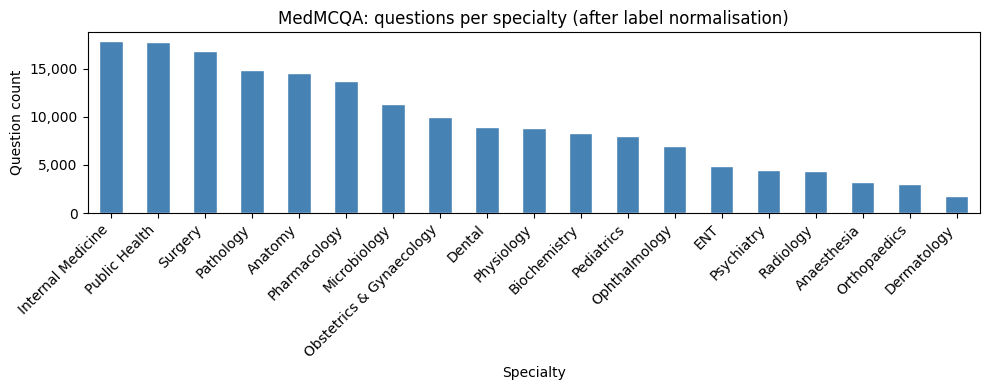

Class imbalance ratio (max/min): 10.1x -> using weighted F1.


In [5]:
# Class distribution
fig, ax = plt.subplots(figsize=(10, 4))
specialty_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Specialty')
ax.set_ylabel('Question count')
ax.set_title('MedMCQA: questions per specialty (after label normalisation)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ratio = specialty_counts.max() / specialty_counts.min()
print(f'Class imbalance ratio (max/min): {ratio:.1f}x -> using weighted F1.')

## 2. Corpus characterisation

Replicate the A1 inter-category cosine similarity analysis on MedMCQA.
A1 found ~0.95 on PubMed AI imaging abstracts (5 tightly clustered categories).
Lower similarity here means more separable categories and possibly better conditions for embeddings.

In [6]:
# TF-IDF inter-category cosine similarity (200 samples per class)
print('Computing inter-category similarity (TF-IDF centroids, 200 samples/class)...')
sim_df = inter_category_similarity(
    mcqa, text_col='question', label_col='specialty', n_per_class=200
)

mask = ~np.eye(len(sim_df), dtype=bool)
mean_sim = sim_df.values[mask].mean()
print(f'Mean inter-category cosine similarity : {mean_sim:.4f}')
print(f'A1 baseline (PubMed AI corpus)        : ~0.9500')
print(f'Delta vs A1                           : {mean_sim - 0.95:+.4f}')
print()
if mean_sim < 0.85:
    print('-> Substantially lower overlap than A1. Embeddings may be competitive.')
elif mean_sim < 0.92:
    print('-> Moderate overlap. TF-IDF expected to lead but gap may narrow.')
else:
    print('-> High overlap similar to A1. TF-IDF expected to dominate.')

Computing inter-category similarity (TF-IDF centroids, 200 samples/class)...
Mean inter-category cosine similarity : 0.7101
A1 baseline (PubMed AI corpus)        : ~0.9500
Delta vs A1                           : -0.2399

-> Substantially lower overlap than A1. Embeddings may be competitive.


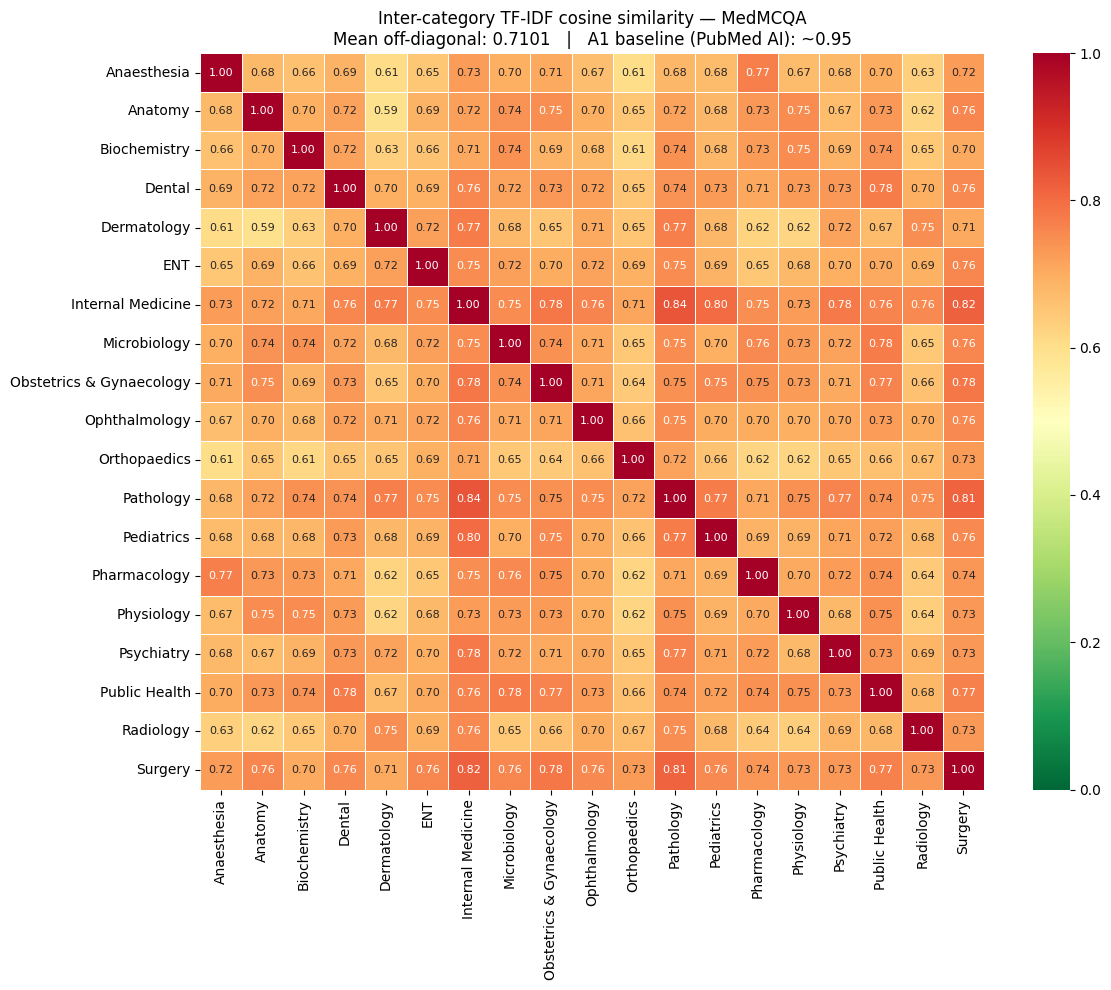

In [ ]:
# Similarity heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    sim_df, annot=True, fmt='.2f', cmap='RdYlGn_r',
    vmin=0.5, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 8},
)
ax.set_title(
    f'Inter-category TF-IDF cosine similarity — MedMCQA\n'
    f'Mean off-diagonal: {mean_sim:.4f}   |   A1 baseline (PubMed AI): ~0.95'
)
plt.tight_layout()
plt.show()

## 3. Feature extraction

Prepare all feature representations for the grid search.

In [8]:
# Encode labels
le     = get_label_encoder(mcqa['specialty'])
y      = le.transform(mcqa['specialty'])
X_text = mcqa['question']

# ── Stratified subsample for CV ──────────────────────────────────────────────
# CV is used for model selection, not final performance estimation.
# A stratified 20k sample preserves class distribution and is sufficient
# to rank configurations reliably, reducing CV runtime from ~10 hrs to ~30 min.
# The champion model is retrained on the full 179k corpus in section 6.
CV_SAMPLE = 20_000

rng        = np.random.default_rng(RANDOM_SEED)
cv_idx     = []
for cls in np.unique(y):
    cls_idx = np.where(y == cls)[0]
    n       = max(1, int(CV_SAMPLE * len(cls_idx) / len(y)))
    cv_idx.extend(rng.choice(cls_idx, size=n, replace=False).tolist())
cv_idx = np.array(cv_idx)

X_cv = X_text.iloc[cv_idx]
y_cv = y[cv_idx]

print(f'Classes ({len(le.classes_)}): {list(le.classes_)}')
print(f'Full corpus  : {len(X_text):,} questions')
print(f'CV sample    : {len(X_cv):,} questions  (stratified {CV_SAMPLE:,})')
print(f'Class distribution preserved: {dict(zip(le.classes_, np.bincount(y_cv)))}')


Classes (19): [np.str_('Anaesthesia'), np.str_('Anatomy'), np.str_('Biochemistry'), np.str_('Dental'), np.str_('Dermatology'), np.str_('ENT'), np.str_('Internal Medicine'), np.str_('Microbiology'), np.str_('Obstetrics & Gynaecology'), np.str_('Ophthalmology'), np.str_('Orthopaedics'), np.str_('Pathology'), np.str_('Pediatrics'), np.str_('Pharmacology'), np.str_('Physiology'), np.str_('Psychiatry'), np.str_('Public Health'), np.str_('Radiology'), np.str_('Surgery')]
Full corpus  : 179,777 questions
CV sample    : 19,990 questions  (stratified 20,000)
Class distribution preserved: {np.str_('Anaesthesia'): np.int64(352), np.str_('Anatomy'): np.int64(1619), np.str_('Biochemistry'): np.int64(921), np.str_('Dental'): np.int64(994), np.str_('Dermatology'): np.int64(197), np.str_('ENT'): np.int64(547), np.str_('Internal Medicine'): np.int64(1989), np.str_('Microbiology'): np.int64(1258), np.str_('Obstetrics & Gynaecology'): np.int64(1113), np.str_('Ophthalmology'): np.int64(771), np.str_('Orth

In [9]:
# Word2Vec embeddings (trained on the MedMCQA corpus itself)
print('Training Word2Vec on MedMCQA questions...')
w2v_model = train_word2vec(X_text.tolist(), vector_size=100, window=5)
X_w2v = embed_word2vec(w2v_model, X_text.tolist())
print(f'Word2Vec matrix: {X_w2v.shape}')

Training Word2Vec on MedMCQA questions...
Word2Vec matrix: (179777, 100)


In [10]:
# Sentence embeddings
# RUN_EMBEDDING_CV = True + USE_FAST_MODEL = True  ->  MiniLM (CPU, ~2 min on 5k)
# RUN_EMBEDDING_CV = True + USE_FAST_MODEL = False ->  Qwen3-0.6B (GPU recommended)
# RUN_EMBEDDING_CV = False                         ->  skip entirely

RUN_EMBEDDING_CV = True
USE_FAST_MODEL   = True           # flip to False on GPU for Qwen3
EMBEDDING_SAMPLE = 5_000          # increase to len(mcqa) on GPU

EMB_MODEL_NAME = 'all-MiniLM-L6-v2' if USE_FAST_MODEL else BIOMEDICAL_MODEL
EMB_LABEL      = 'MiniLM-L6-v2 (CPU proxy)' if USE_FAST_MODEL else 'Qwen3-Embedding-0.6B'

if RUN_EMBEDDING_CV:
    rng         = np.random.default_rng(RANDOM_SEED)
    sample_idx  = rng.choice(len(mcqa), size=EMBEDDING_SAMPLE, replace=False)
    mcqa_sample = mcqa.iloc[sample_idx].reset_index(drop=True)
    y_sample    = y[sample_idx]

    print(f'Embedding model  : {EMB_MODEL_NAME}')
    print(f'Embedding sample : {EMBEDDING_SAMPLE:,} questions')
    emb_model = load_embedding_model(EMB_MODEL_NAME)
    X_emb     = embed_texts(mcqa_sample['question'].tolist(), emb_model, batch_size=32)
    X_w2v_sample = X_w2v[sample_idx]
    print(f'Embedding matrix : {X_emb.shape}')
else:
    X_emb, y_sample, mcqa_sample, emb_model = None, None, None, None
    X_w2v_sample = None
    print('Embedding CV skipped (RUN_EMBEDDING_CV=False).')

Embedding model  : all-MiniLM-L6-v2
Embedding sample : 5,000 questions
[Vectorstore] GPU memory: 14.5 GB free / 14.6 GB total


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[Vectorstore] Embedding model: all-MiniLM-L6-v2  (dtype=torch.float16, device=cuda)


Embedding chunks: 100%|██████████| 5,000/5,000 [00:03<00:00, 1541.82chunk/s]

Embedding matrix : (5000, 384)


## 4. Feature x Classifier grid search

10-fold stratified CV on all feature x classifier combinations.
Frequency-based features run on full 182k corpus.
Embedding features run on the sample (see section 3).
Progress is shown per fold.

### 4.1. Feature x Classifier grid
Grid: 4 feature types x 3 classifiers = 12 configs (+ 1 embedding config)

|                   | BOW | TF-IDF Bigrams | Word2Vec | all-MiniLM-L6-v2 | Justification     |
|------------------:|:---:|:--------------:|:--------:|:----------------:|:------------------|
| **LinearSVC**     | x | x | x | x | A1 #1 classifier across most feature types; exact SVM  |
| **MNB**           | x | x |   |   | A1 #2 overall; native sparse support; extremely fast   |

<div class="alert alert-block alert-info">
    <div style="padding-bottom: 10px; font-size: 1.2em;">
        <b>ⓘ Note</b>
    </div>
    MNB requires non-negative features, so it is only compatible with BOW and TF-IDF (which produce non-negative values). It cannot be used with Word2Vec or sentence embeddings (which have negative values).
</div>

#### 4.2. Classifiers Excluded

| # | Classifier | Justification |
|---|-----------:|---------------|
| 1 | SGD        | Approximate SVM. With exact LinearSVC already in the grid, SGD adds only a noisier version of the same thing. |
| 2 | LR          | Logistic Regression. Consistently outperformed by LinearSVC on high-dimensional sparse text in A1 and the literature. |
| 3 | XGBoost / CatBoost / LightGBM | Gradient boosting does not handle sparse matrices natively. Dense conversion of a 50k-feature TF-IDF matrix would be memory-prohibitive. All three were mid-table in A1 and below LinearSVC and Random Forest. |
| 4 | KNN         | O(n) prediction cost on 180k samples makes this genuinely impractical for inference. Would not be deployable. |
| 5 | DistilBERT  | Requires fine-tuning on this corpus. Out of scope for a routing component whose job is specialty prediction, not QA. |
| 6 | Random Forest | Evaluated empirically on TF-IDF Bigrams (20k CV sample, Colab T4). Each fold took ~4 min (vs ~5s for LinearSVC),with mean F1=0.42 vs LinearSVC's 0.68 on the same data —a 26-point gap. The root cause is structural: Random Forestevaluates split candidates across all features at each node.On a 50k-dimensional sparse TF-IDF matrix, most featuresare zero for any given document, so the vast majority ofsplit evaluations are wasted computation on uninformativethresholds. Linear models like LinearSVC exploit sparsitydirectly and are the empirically and theoretically correctchoice for this feature space. RF was included in A1 becausethe corpus was substantially smaller; at 20k x 50k it isneither competitive nor practical. |

#### 4.3. Features / Embeddings Excluded

| # | Feature              | Justification |
|---|---------------------:|---------------|
| 1 | TF (no IDF)          | Strictly dominated by TF-IDF in theory and practice. |
| 2 | TF-IDF unigrams      | Subsumed by bigrams -- bigrams are always >= unigrams. |
| 3 | Trigrams / Combined N-grams | A1 Combined N-grams = unigrams+bigrams+trigrams. Trigrams add noise on short questions (~10-20 words); the MedMCQA question stems are too short to benefit. |
| 4 | Doc2Vec             | Requires paragraph ID training; cannot embed unseen questions at inference time without retraining. |
| 5 | LDA                 | Topic model -- produces topic distributions, not discriminative document features. Poorly suited to fine-grained 21-class classification. |
| 6 | FastText            | Subword embeddings add value for morphologically rich languages or noisy text. Medical question stems are clean and standardised; Word2Vec covers this adequately. |

In [ ]:
class EmbeddingPipeline:
    """Wrapper so pre-computed embeddings work with cross_validate_pipeline."""
    def __init__(self, clf): self.clf = clf
    def fit(self, X, y):     self.clf.fit(X, y); return self
    def predict(self, X):    return self.clf.predict(X)

cv_corpus_label     = f'{len(X_cv):,} (CV sample)'
sample_corpus_label = f'{EMBEDDING_SAMPLE:,} (sample)' if RUN_EMBEDDING_CV else 'N/A'

configs = [
    # ── BOW ──────────────────────────────────────────────────────────────────
    {'name': 'BOW + LinearSVC',    'pipeline': build_bow_pipeline('LinearSVC'), 'X': X_cv,          'y': y_cv, 'corpus': cv_corpus_label},
    {'name': 'BOW + MNB',          'pipeline': build_bow_pipeline('MNB'),       'X': X_cv,          'y': y_cv, 'corpus': cv_corpus_label},
    {'name': 'BOW + RF',           'pipeline': build_bow_pipeline('RF'),        'X': X_cv,          'y': y_cv, 'corpus': cv_corpus_label},
    # ── TF-IDF Bigrams ───────────────────────────────────────────────────────
    {'name': 'TF-IDF Bigrams + LinearSVC', 'pipeline': build_tfidf_pipeline('LinearSVC', ngram_range=(1,2)), 'X': X_cv, 'y': y_cv, 'corpus': cv_corpus_label},
    {'name': 'TF-IDF Bigrams + MNB',       'pipeline': build_tfidf_pipeline('MNB',        ngram_range=(1,2)), 'X': X_cv, 'y': y_cv, 'corpus': cv_corpus_label},
    {'name': 'TF-IDF Bigrams + RF',        'pipeline': build_tfidf_pipeline('RF',         ngram_range=(1,2)), 'X': X_cv, 'y': y_cv, 'corpus': cv_corpus_label},
    # ── Word2Vec (dense -- no MNB) ───────────────────────────────────────────
    {'name': 'Word2Vec + LinearSVC', 'pipeline': EmbeddingPipeline(build_embedding_clf('LinearSVC')), 'X': X_w2v[cv_idx], 'y': y_cv, 'corpus': cv_corpus_label},
    {'name': 'Word2Vec + RF',        'pipeline': EmbeddingPipeline(build_embedding_clf('RF')),        'X': X_w2v[cv_idx], 'y': y_cv, 'corpus': cv_corpus_label},
]

if RUN_EMBEDDING_CV:
    # Sentence embeddings -- dense, so no MNB
    configs += [
        {'name': f'{EMB_LABEL} + LinearSVC', 'pipeline': EmbeddingPipeline(build_embedding_clf('LinearSVC')), 'X': X_emb, 'y': y_sample, 'corpus': sample_corpus_label},
        {'name': f'{EMB_LABEL} + RF',        'pipeline': EmbeddingPipeline(build_embedding_clf('RF')),        'X': X_emb, 'y': y_sample, 'corpus': sample_corpus_label},
    ]

n_configs = len(configs)
print(f'Grid: {n_configs} configs x 10 folds = {n_configs * 10} fits')
print(f'CV sample   : {len(X_cv):,} questions (stratified)')
print(f'Classifiers : LinearSVC, MNB (BOW/TF-IDF only), Random Forest')
print(f'Features    : BOW, TF-IDF Bigrams, Word2Vec, {EMB_LABEL}')
print(f'Note: MNB excluded from Word2Vec/embedding configs (requires non-negative features)')


Grid: 10 configs x 10 folds = 100 fits
CV sample   : 19,990 questions (stratified)
Classifiers : LinearSVC, MNB (BOW/TF-IDF only), Random Forest
Features    : BOW, TF-IDF Bigrams, Word2Vec, MiniLM-L6-v2 (CPU proxy)
Note: MNB excluded from Word2Vec/embedding configs (requires non-negative features)


In [12]:
# Run the grid
# Per-fold output: config number, F1, kappa, elapsed time, running mean.
results_df = run_grid(configs, y=y_cv, n_splits=10)


=== Feature x Classifier Grid: 10 configs x 10 folds = 100 fits ===

[1/10] BOW + LinearSVC  (19,990 samples, 10 folds)


     10%|█         | 1/10 folds [00:04<00:41]

    Fold  1/10 | F1=0.5178  kappa=0.4828  (4.6s) | running mean -> F1=0.5178  kappa=0.4828


     20%|██        | 2/10 folds [00:09<00:36]

    Fold  2/10 | F1=0.4931  kappa=0.4566  (4.6s) | running mean -> F1=0.5055  kappa=0.4697


...

     50%|█████     | 5/10 folds [20:10<20:07]

    Fold  5/10 | F1=0.4168  kappa=0.3745  (238.9s) | running mean -> F1=0.4155  kappa=0.3743


     60%|██████    | 6/10 folds [24:02<15:54]

    Fold  6/10 | F1=0.3959  kappa=0.3549  (232.6s) | running mean -> F1=0.4122  kappa=0.3711


KeyboardInterrupt: 

In [ ]:
# Results table (sorted by F1, drop internal _cv column)
display_df = (
    results_df
    .drop(columns=['_cv'])
    .sort_values('Weighted F1', ascending=False)
    .reset_index(drop=True)
)
display(display_df)

# Champion
champion_row = results_df.sort_values(
    by=results_df['_cv'].apply(lambda d: d['mean_f1']).values.tolist(),
    ascending=False
).iloc[0]

# Get champion by highest mean_f1
best_idx = max(range(len(results_df)), key=lambda i: results_df.iloc[i]['_cv']['mean_f1'])
champion_row = results_df.iloc[best_idx]
print(f'\nChampion: {champion_row["Configuration"]}')
print(f'  Weighted F1  : {champion_row["Weighted F1"]}')
print(f'  Cohen\'s kappa: {champion_row["Cohen\'s kappa"]}')

if not RUN_EMBEDDING_CV:
    print('\nNote: Embedding comparison skipped. Set RUN_EMBEDDING_CV=True to include.')
elif USE_FAST_MODEL:
    print('\nNote: Embedding rows use MiniLM-L6-v2 as CPU proxy for Qwen3-Embedding-0.6B.')
    print('      Set USE_FAST_MODEL=False on GPU for the full Qwen3 comparison.')

## 5. Error analysis

90/10 holdout split using the champion configuration for confusion matrix and per-class breakdown.

In [ ]:
# Fit champion on 90%, evaluate on 10%
# Default to TF-IDF Bigrams + LinearSVC (A1 champion config)
# Update pipeline here if grid search found a different champion
champion_pipeline = build_tfidf_pipeline(classifier='LinearSVC', ngram_range=(1, 2))

X_tr, X_val, y_tr, y_val = train_test_split(
    X_text, y, test_size=0.1, stratify=y, random_state=RANDOM_SEED
)
champion_pipeline.fit(X_tr, y_tr)
y_pred = champion_pipeline.predict(X_val)

val_f1    = f1_score(y_val, y_pred, average='weighted', zero_division=0)
val_kappa = cohen_kappa_score(y_val, y_pred)
print(f'Holdout weighted F1 : {val_f1:.4f}')
print(f"Holdout Cohen's kappa: {val_kappa:.4f}")
print()
print_classification_report(y_val, y_pred, le)

In [ ]:
# Normalised confusion matrix
cm = confusion_matrix(y_val, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(14, 11))
ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=le.classes_
).plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f', xticks_rotation=45)
ax.set_title('Normalised confusion matrix — champion configuration')
plt.tight_layout()
plt.show()

In [ ]:
# Most confused pairs
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
np.fill_diagonal(cm_df.values, 0)

confused_pairs = (
    cm_df.stack()
    .reset_index()
    .rename(columns={'level_0': 'true', 'level_1': 'predicted', 0: 'rate'})
    .sort_values('rate', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print('Top 10 confused specialty pairs (true -> predicted):')
display(confused_pairs)

## 6. Train final model and save

In [ ]:
# Train champion on full MedMCQA corpus
print('Training champion on full corpus...')
final_pipeline = build_tfidf_pipeline(classifier='LinearSVC', ngram_range=(1, 2))
final_pipeline = train_classifier(X_text, y, pipeline=final_pipeline)
print('Done.')

# Save
champion_cv = results_df.iloc[
    max(range(len(results_df)), key=lambda i: results_df.iloc[i]['_cv']['mean_f1'])
]['_cv']

with open(CLASSIFIER_DIR / 'tfidf_svm.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)
with open(CLASSIFIER_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

config = {
    'champion':        champion_row['Configuration'],
    'features':        'TF-IDF (1,2)-gram',
    'classifier':      'LinearSVC',
    'max_features':    50_000,
    'ngram_range':     [1, 2],
    'train_size':      len(mcqa),
    'n_classes':       len(le.classes_),
    'classes':         list(le.classes_),
    'cv_f1_mean':      round(champion_cv['mean_f1'], 4),
    'cv_kappa_mean':   round(champion_cv['mean_kappa'], 4),
    'mean_inter_sim':  round(float(mean_sim), 4),
    'embedding_note':  EMB_LABEL if RUN_EMBEDDING_CV else 'skipped',
}
with open(CLASSIFIER_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f'\nSaved to {CLASSIFIER_DIR}:')
for p in sorted(CLASSIFIER_DIR.glob('*')):
    print(f'  {p.name:30s}  {p.stat().st_size/1024:.1f} KB')

## 7. Apply to MedQA

Apply the trained classifier to all MedQA questions to produce specialty
routing tags for downstream RAG retrieval.

In [ ]:
medqa_all = load_medqa_all()
medqa_all['specialty'] = predict_specialty(medqa_all['question'], final_pipeline, le)

print(f'MedQA specialty distribution ({len(medqa_all):,} questions):')
display(medqa_all['specialty'].value_counts().reset_index())

In [ ]:
# Sanity check — sample predictions
print('Sample MedQA predictions:')
for _, row in medqa_all[['question', 'specialty']].sample(8, random_state=RANDOM_SEED).iterrows():
    print(f'  [{row.specialty:30s}]  {row.question[:90]}...')

In [ ]:
# Save labelled MedQA for downstream notebooks
medqa_out = CLASSIFIER_DIR / 'medqa_with_specialty.parquet'
medqa_all[['question', 'options', 'answer_idx', 'answer', 'split', 'specialty']].to_parquet(
    medqa_out, index=False
)
print(f'Saved -> {medqa_out}  ({medqa_out.stat().st_size/1024:.0f} KB)')

In [ ]:
# ── COLAB ONLY: copy outputs to Google Drive ─────────────────────────────────
# Run this after section 6 saves locally. Skip if running locally.
# -----------------------------------------------------------------------------

# import shutil
# for f in CLASSIFIER_DIR.glob('*'):
#     shutil.copy(f, DRIVE_OUT / f.name)
#     print(f'  Saved {f.name} ({f.stat().st_size/1024:.1f} KB) -> Drive')
# print(f'Outputs saved to {DRIVE_OUT}')


## 8. Summary

In [ ]:
config = json.loads((CLASSIFIER_DIR / 'config.json').read_text())

summary_df = pd.DataFrame([
    {'Item': 'Training corpus',          'Value': f"MedMCQA train  ({config['train_size']:,} questions)"},
    {'Item': 'Specialties',              'Value': str(config['n_classes'])},
    {'Item': 'Champion config',          'Value': config['champion']},
    {'Item': 'Features',                 'Value': config['features']},
    {'Item': 'Classifier',               'Value': config['classifier']},
    {'Item': 'CV weighted F1',           'Value': f"{config['cv_f1_mean']:.4f}"},
    {'Item': "CV Cohen's kappa",         'Value': f"{config['cv_kappa_mean']:.4f}"},
    {'Item': 'Mean inter-category sim',  'Value': f"{config['mean_inter_sim']:.4f}  (A1 baseline ~0.95)"},
    {'Item': 'Embedding comparison',     'Value': config['embedding_note']},
    {'Item': 'MedQA questions labelled', 'Value': f"{len(medqa_all):,}"},
    {'Item': 'Model saved',              'Value': str(CLASSIFIER_DIR / 'tfidf_svm.pkl')},
])

display(summary_df)

### Next step: Notebook 03: Clustering — BERTopic topic discovery on MedQA by specialty.